This step installs additional Python libraries required for the project.

imbalanced-learn	-Used for SMOTE to solve class imbalance

xgboost-	Used to train the XGBoost model

shap	-Used for explainable AI and model interpretation

In [1]:
!pip install imbalanced-learn xgboost shap

Import Libraries-
These libraries are used for:
handling data
numerical operations
creating graphs and visualisations

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

It prepares the dataset for machine learning training.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

These metrics are used to evaluate machine learning performance.

Important

For fraud detection:

Recall and F1-score are more important than accuracy because fraud datasets are imbalanced.

In [4]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)


These are the machine learning algorithms used in the project.

Model	Purpose
Logistic Regression	Baseline classification model

Decision Tree	Tree-based classification

Random Forest	Ensemble learning

SVM	Complex boundary classification

XGBoost	Advanced boosting algorithm

SMOTE	Balances fraud/non-fraud data

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

Load Dataset

In [1]:
from google.colab import files
import pandas as pd
import io

print('Please upload the creditcard.csv file from your computer:')
uploaded = files.upload()

# Get the filename from the uploaded dictionary
file_name = list(uploaded.keys())[0]

# Load the dataset
data = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f'Successfully loaded {file_name}')
display(data.head())

Please upload the creditcard.csv file from your computer:


Saving creditcard.csv to creditcard.csv
Successfully loaded creditcard.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Check Dataset

This step checks:

dataset size

data types

missing values

fraud distribution

In [2]:
print(data.shape)
print(data.info())
print(data.isnull().sum())
print(data['Class'].value_counts())

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

Visualise Class Imbalance

This creates a graph showing fraud and non-fraud transaction counts.

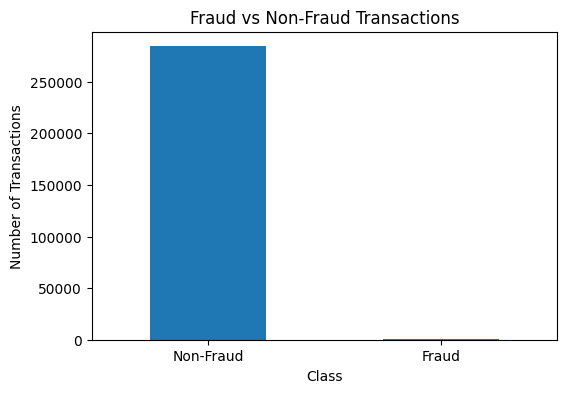

Fraud percentage: 0.1727485630620034


In [4]:
import matplotlib.pyplot as plt

class_counts = data['Class'].value_counts()

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')
plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'], rotation=0)
plt.show()

fraud_percentage = (class_counts[1] / len(data)) * 100
print("Fraud percentage:", fraud_percentage)

Prepare Features and Target

The machine learning models will learn patterns from X to predict y.


In [5]:
X = data.drop('Class', axis=1)
y = data['Class']

Scale Numerical Features

Feature scaling was applied to Time and Amount to improve model performance and stability.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

Split Training and Testing Data

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Training class distribution:")
print(y_train.value_counts())

Training set: (227845, 30)
Testing set: (56962, 30)
Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64


Baseline Model Without SMOTE

This trains a simple Logistic Regression model before balancing the dataset.

Although the baseline model achieved high accuracy, its fraud detection performance was limited due to class imbalance.



In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

baseline_model = LogisticRegression(max_iter=1000, random_state=42)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_prob = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression Without SMOTE")
print(classification_report(y_test, baseline_pred))

print("ROC-AUC:", roc_auc_score(y_test, baseline_prob))

Baseline Logistic Regression Without SMOTE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9572835078037969


Apply SMOTE

SMOTE was applied only to the training data to avoid data leakage and improve fraud learning capability.


In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


Define Models

This defines all machine learning algorithms used in the study.


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=6
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ),

    "Support Vector Machine": SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        eval_metric='logloss'
    )
}

Train and Evaluate Models
It compares all models fairly using the same dataset.

In [11]:
# ==============================
# Fast Credit Card Fraud Detection Models
# ==============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# ==============================
# 1. Load data
# ==============================

try:
    data
    print("Dataset already loaded.")
except NameError:
    print("Loading dataset...")
    data = pd.read_csv('/content/creditcard.csv')

# ==============================
# 2. Prepare X and y
# ==============================

X = data.drop('Class', axis=1).copy()
y = data['Class'].copy()

# ==============================
# 3. Scale Time and Amount
# ==============================

scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

# ==============================
# 4. Split data
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==============================
# 5. Apply faster SMOTE
# ==============================

smote = SMOTE(
    sampling_strategy=0.2,
    random_state=42,
    k_neighbors=3
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# ==============================
# 6. Define fast models
# ==============================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver='liblinear',
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )
}

# ==============================
# 7. Train and evaluate models
# ==============================

results = []
trained_models = {}

for model_name, model in models.items():
    print("\nTraining:", model_name)

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

    trained_models[model_name] = model

    print(classification_report(y_test, y_pred, zero_division=0))
    print("-" * 60)

# ==============================
# 8. Display results table
# ==============================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-score", ascending=False)

display(results_df)

Dataset already loaded.
Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1     45490
Name: count, dtype: int64

Training: Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.20      0.89      0.33        98

    accuracy                           0.99     56962
   macro avg       0.60      0.94      0.66     56962
weighted avg       1.00      0.99      1.00     56962

------------------------------------------------------------

Training: Decision Tree
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.18      0.85      0.29        98

    accuracy                           0.99     56962
   macro avg       0.59      0.92      0.64     56962
weighted avg       1.00      0.99      1.00     56962

------------------------------------------------------------

Tra

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Random Forest,0.997999,0.456522,0.857143,0.595745,0.978966
3,XGBoost,0.996700,0.329545,0.887755,0.480663,0.974371
0,Logistic Regression,0.993838,0.203747,0.887755,0.331429,0.969602
1,Decision Tree,0.992908,0.175847,0.846939,0.291228,0.906471


Results Table

F1-score was selected as the primary ranking metric because it balances fraud detection capability and false alarm reduction.

In [12]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1-score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Random Forest,0.997999,0.456522,0.857143,0.595745,0.978966
3,XGBoost,0.996700,0.329545,0.887755,0.480663,0.974371
0,Logistic Regression,0.993838,0.203747,0.887755,0.331429,0.969602
1,Decision Tree,0.992908,0.175847,0.846939,0.291228,0.906471


Plot Model Comparison

The tallest bar indicates the best-performing model.

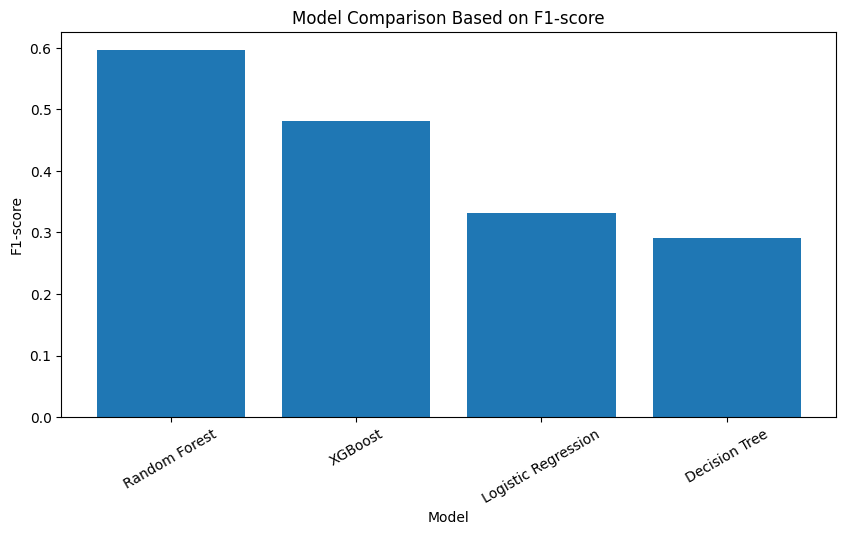

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(results_df['Model'], results_df['F1-score'])
plt.title('Model Comparison Based on F1-score')
plt.xlabel('Model')
plt.ylabel('F1-score')
plt.xticks(rotation=30)
plt.show()

Select Best Model

This automatically selects the highest F1-score model

In [15]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

Best model: Random Forest


Confusion Matrix

The confusion matrix shows:

correct predictions
incorrect predictions

Expected Result

True Positive	Correct fraud detection

False Negative	Missed fraud

False Positive	False alarm

False negatives are very dangerous in fraud detection.

Top-Left (True Negatives): The number of legitimate transactions correctly identified.

Bottom-Right (True Positives): The number of fraudulent transactions correctly caught.

Top-Right (False Positives): Legitimate transactions flagged as fraud (false alarms).

Bottom-Left (False Negatives): Fraudulent transactions that the model missed.

In fraud detection, we aim to minimize the Bottom-Left quadrant as much as possible, as missed fraud is typically more costly than a false alarm.

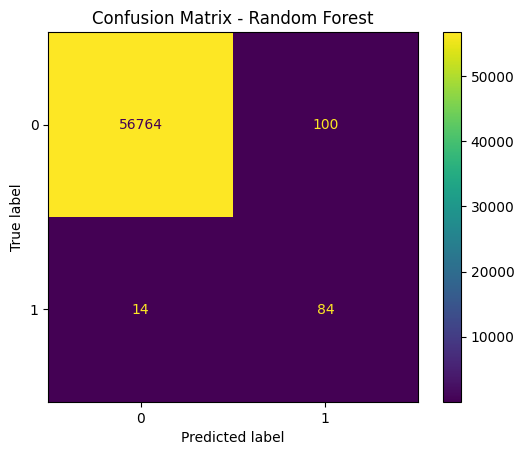

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions from the best model identified previously
best_pred = best_model.predict(X_test)

# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, best_pred)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

ROC Curve

Explanation

The ROC curve evaluates classification quality.

Expected Result

Curve near top-left corner = strong model

Higher ROC-AUC = better fraud separation

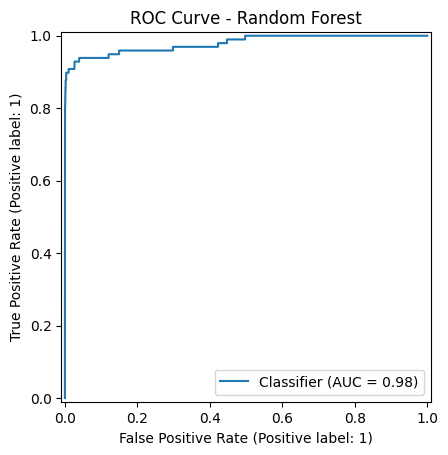

In [19]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

best_prob = best_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, best_prob)
plt.title(f'ROC Curve - {best_model_name}')
plt.show()

Precision-Recall Curve

Explanation

This is especially important for imbalanced datasets.

Expected Result

Good models maintain:

high precision
high recall

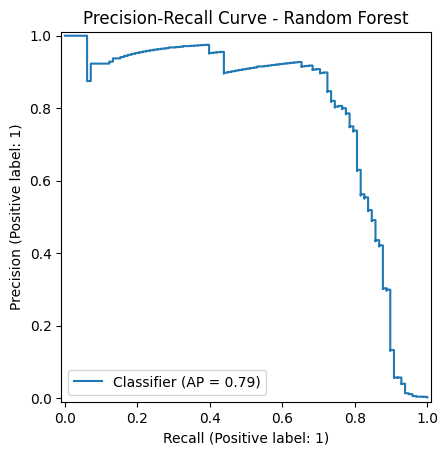

In [21]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Display the Precision-Recall curve
PrecisionRecallDisplay.from_predictions(y_test, best_prob)
plt.title(f'Precision-Recall Curve - {best_model_name}')
plt.show()

Feature Importance

Explanation

This identifies the most influential transaction features.


What This Will Do

Improves model explainability.


Expected Result

Top features contribute most to fraud predictions.

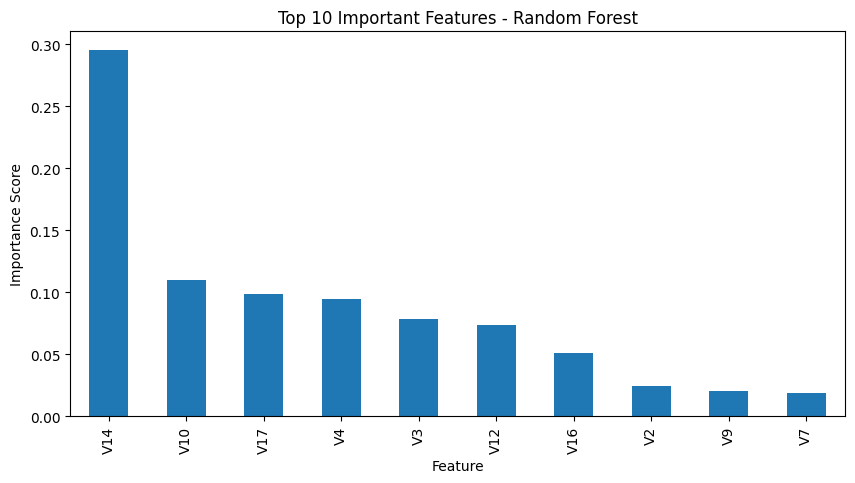

V14    0.295669
V10    0.110114
V17    0.098390
V4     0.094463
V3     0.078941
V12    0.073395
V16    0.051114
V2     0.024493
V9     0.020597
V7     0.019074
dtype: float64


In [22]:
if best_model_name in ["Random Forest", "XGBoost"]:
    feature_importance = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(10,5))
    feature_importance.head(10).plot(kind='bar')
    plt.title(f'Top 10 Important Features - {best_model_name}')
    plt.xlabel('Feature')
    plt.ylabel('Importance Score')
    plt.show()

    print(feature_importance.head(10))
else:
    print("Feature importance is not directly available for this model.")

SHAP Explainability

Explanation

SHAP explains:

why predictions happen
which features increase fraud probability
What This Will Do

Makes the AI system transparent and explainable.



SHAP analysis was applied to improve interpretability and understand how individual features influenced fraud predictions.

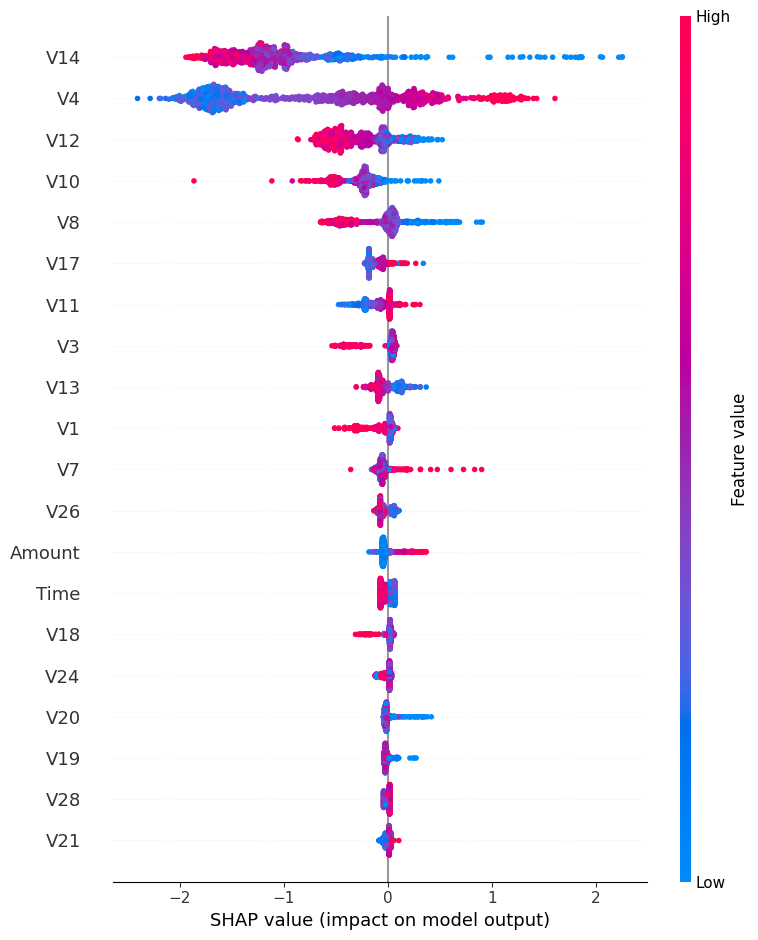

In [23]:
import shap

xgb_model = trained_models["XGBoost"]

sample_X_test = X_test.sample(1000, random_state=42)

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(sample_X_test)

shap.summary_plot(shap_values, sample_X_test)

Predict One Transaction

Explanation

This predicts whether one transaction is fraud.

What This Will Do


Useful for:

live demonstration
showing real prediction output

In [24]:
sample_transaction = X_test.iloc[[0]]

prediction = best_model.predict(sample_transaction)
probability = best_model.predict_proba(sample_transaction)[:, 1]

if prediction[0] == 1:
    print("Prediction: Fraud")
else:
    print("Prediction: Non-Fraud")

print("Fraud probability:", probability[0])

Prediction: Non-Fraud
Fraud probability: 0.010379527348499151


Cross Validation

In [31]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print("Cross Validation F1 Scores:", cv_scores)
print("Average CV F1 Score:", cv_scores.mean())

Cross Validation F1 Scores: [0.9878614  0.98912624 0.98723404 0.98795048 0.98813924]
Average CV F1 Score: 0.9880622783973841


Hyperparameter Tuning

Hyperparameter optimisation was performed using GridSearchCV to identify the optimal XGBoost configuration.

In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [50, 100]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
Best F1 Score:
0.9765391449317519


Save Results

In [25]:
results_df.to_csv('model_comparison_results.csv', index=False)

Compare Before and After SMOTE

In [34]:
from sklearn.metrics import f1_score
import pandas as pd

# Ensure baseline_pred is calculated if it doesn't exist
try:
    baseline_pred = baseline_model.predict(X_test)
except NameError:
    # Fallback in case baseline_model was also lost
    from sklearn.linear_model import LogisticRegression
    temp_baseline = LogisticRegression(max_iter=1000, random_state=42)
    temp_baseline.fit(X_train, y_train)
    baseline_pred = temp_baseline.predict(X_test)

before_smote = {
    "Model": "Baseline Logistic Regression",
    "F1-score": f1_score(y_test, baseline_pred)
}

after_smote = {
    "Model": best_model_name,
    "F1-score": results_df.iloc[0]['F1-score']
}

comparison_df = pd.DataFrame([before_smote, after_smote])
display(comparison_df)

,Model,F1-score
0,Baseline Logistic Regression,0.724138
1,Random Forest,0.595745


feature Correlation Heatmap

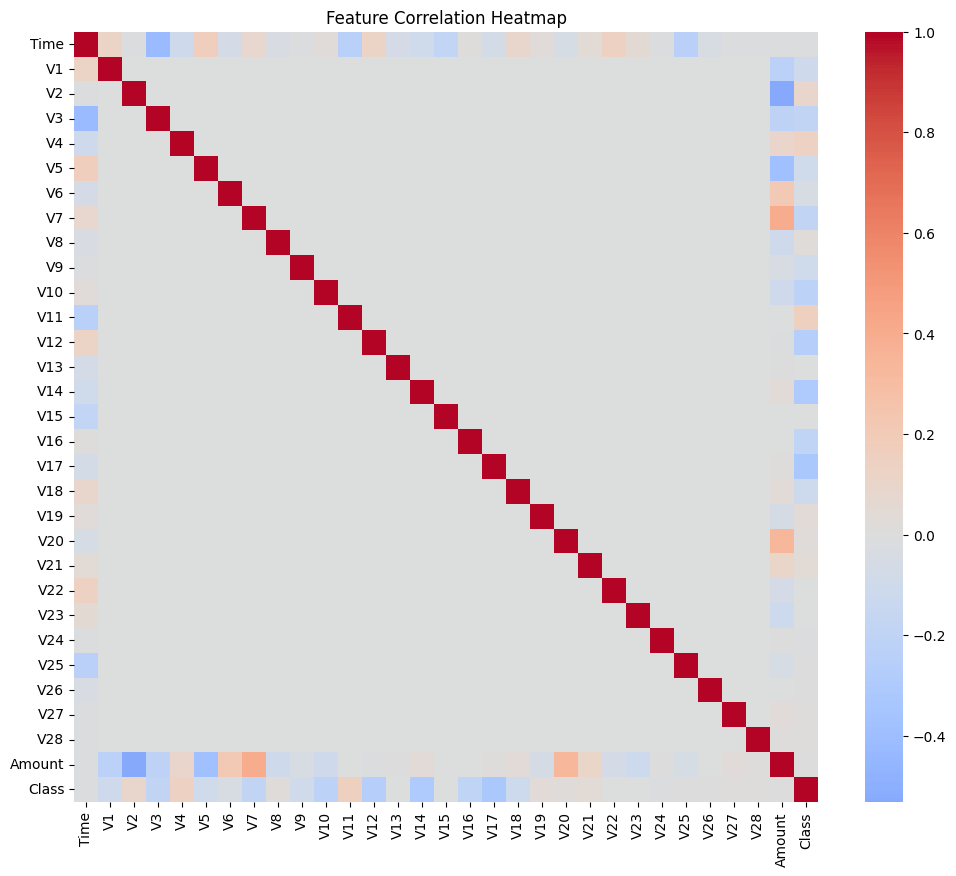

In [35]:
import seaborn as sns

plt.figure(figsize=(12,10))

sns.heatmap(
    data.corr(),
    cmap='coolwarm',
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

Fraud Probability Distribution

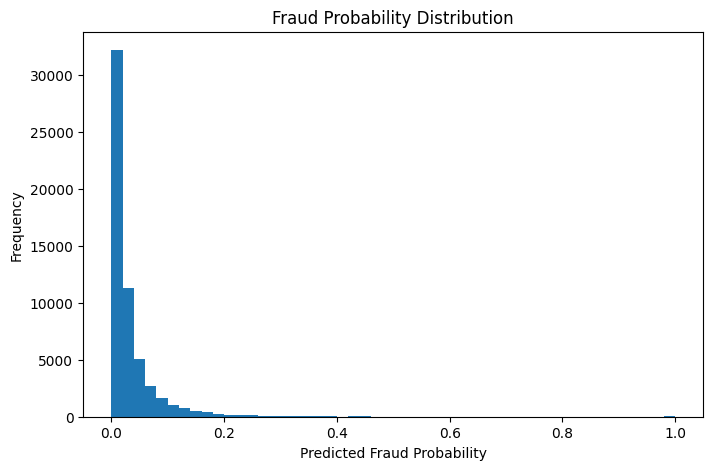

In [36]:
plt.figure(figsize=(8,5))

plt.hist(best_prob, bins=50)

plt.title("Fraud Probability Distribution")
plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Frequency")

plt.show()

Threshold Optimization

In [37]:
thresholds = [0.3, 0.5, 0.7]

for threshold in thresholds:

    custom_pred = (best_prob >= threshold).astype(int)

    print("\nThreshold:", threshold)

    print(classification_report(y_test, custom_pred))


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.18      0.90      0.30        98

    accuracy                           0.99     56962
   macro avg       0.59      0.95      0.65     56962
weighted avg       1.00      0.99      1.00     56962


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.46      0.86      0.60        98

    accuracy                           1.00     56962
   macro avg       0.73      0.93      0.80     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.7
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.81      0.75        98

    accuracy                           1.00     56962
   macro avg       0.85      0.90      0.87     56962
weighted avg       1.00   

Save Best Model

In [38]:
import joblib

joblib.dump(best_model, 'best_fraud_detection_model.pkl')

print("Best model saved successfully.")

Best model saved successfully.


Load Saved Model

In [39]:
loaded_model = joblib.load('best_fraud_detection_model.pkl')

sample_prediction = loaded_model.predict(X_test.iloc[[0]])

print(sample_prediction)

[0]


Final Summary

In [26]:
print("Final Project Summary")
print("----------------------")
print("Dataset: Credit Card Fraud Detection")
print("Problem Type: Binary Classification")
print("Imbalance Handling Method: SMOTE")
print("Models Used: Logistic Regression, Decision Tree, Random Forest, SVM, XGBoost")
print("Best Model:", best_model_name)
print("Best F1-score:", results_df.iloc[0]['F1-score'])
print("Best ROC-AUC:", results_df.iloc[0]['ROC-AUC'])

Final Project Summary
----------------------
Dataset: Credit Card Fraud Detection
Problem Type: Binary Classification
Imbalance Handling Method: SMOTE
Models Used: Logistic Regression, Decision Tree, Random Forest, SVM, XGBoost
Best Model: Random Forest
Best F1-score: 0.5957446808510638
Best ROC-AUC: 0.9789661943139664


Fraud prediction demo

In [27]:
sample_transaction = X_test.iloc[[0]]

prediction = best_model.predict(sample_transaction)
probability = best_model.predict_proba(sample_transaction)[:, 1]

print("Prediction:", "Fraud" if prediction[0] == 1 else "Non-Fraud")
print("Fraud Probability:", probability[0])

Prediction: Non-Fraud
Fraud Probability: 0.010379527348499151


In [40]:
import os
import zipfile
from google.colab import files

# Create output folders if they do not exist
os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# Save results table if it exists
try:
    results_df.to_csv("outputs/model_comparison_results.csv", index=False)
    print("Saved: outputs/model_comparison_results.csv")
except NameError:
    print("results_df not found")

# Save error analysis if it exists
try:
    error_analysis.to_csv("outputs/error_analysis.csv", index=False)
    print("Saved: outputs/error_analysis.csv")
except NameError:
    print("error_analysis not found")

# Save best model if it exists
try:
    import joblib
    joblib.dump(best_model, "outputs/best_fraud_detection_model.pkl")
    print("Saved: outputs/best_fraud_detection_model.pkl")
except NameError:
    print("best_model not found")

# Create requirements.txt
requirements = """pandas
numpy
matplotlib
scikit-learn
imbalanced-learn
xgboost
shap
joblib
"""

with open("outputs/requirements.txt", "w") as file:
    file.write(requirements)

print("Saved: outputs/requirements.txt")

# Create README.md
readme_text = """
# Credit Card Fraud Detection Project

This project applies machine learning models to detect fraudulent credit card transactions.

## Models Used
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

## Techniques Used
- Data preprocessing
- Feature scaling
- SMOTE
- Model comparison
- Confusion matrix
- ROC curve
- Precision-recall curve
- Feature importance
- Error analysis

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
"""

with open("outputs/README.md", "w") as file:
    file.write(readme_text)

print("Saved: outputs/README.md")

# Show all files in outputs and figures
print("\nFiles saved in outputs folder:")
for root, dirs, file_names in os.walk("outputs"):
    for file_name in file_names:
        print(os.path.join(root, file_name))

print("\nFiles saved in figures folder:")
for root, dirs, file_names in os.walk("figures"):
    for file_name in file_names:
        print(os.path.join(root, file_name))

# Zip outputs and figures together
zip_filename = "fraud_detection_project_outputs.zip"

with zipfile.ZipFile(zip_filename, "w") as zip_file:
    for folder in ["outputs", "figures"]:
        for root, dirs, file_names in os.walk(folder):
            for file_name in file_names:
                file_path = os.path.join(root, file_name)
                zip_file.write(file_path)

print("\nZIP file created:", zip_filename)

# Download the zip file
files.download(zip_filename)

Saved: outputs/model_comparison_results.csv
error_analysis not found
Saved: outputs/best_fraud_detection_model.pkl
Saved: outputs/requirements.txt
Saved: outputs/README.md

Files saved in outputs folder:
outputs/best_fraud_detection_model.pkl
outputs/README.md
outputs/model_comparison_results.csv
outputs/requirements.txt

Files saved in figures folder:

ZIP file created: fraud_detection_project_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
# ==============================
# Save ALL Figures Automatically
# ==============================

import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Create figures folder
os.makedirs("figures", exist_ok=True)

# ==============================
# 1. Class Distribution
# ==============================

plt.figure(figsize=(6,4))

class_counts = data['Class'].value_counts()

class_counts.plot(kind='bar')

plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')

plt.xticks([0,1], ['Non-Fraud', 'Fraud'], rotation=0)

plt.savefig('figures/class_distribution.png', dpi=300, bbox_inches='tight')

plt.close()

# ==============================
# 2. Model Comparison
# ==============================

plt.figure(figsize=(10,5))

plt.bar(results_df['Model'], results_df['F1-score'])

plt.title('Model Comparison Based on F1-score')
plt.xlabel('Model')
plt.ylabel('F1-score')

plt.xticks(rotation=30)

plt.savefig('figures/model_comparison.png', dpi=300, bbox_inches='tight')

plt.close()

# ==============================
# 3. Confusion Matrix
# ==============================

best_pred = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, best_pred)

plt.title(f'Confusion Matrix - {best_model_name}')

plt.savefig('figures/confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.close()

# ==============================
# 4. ROC Curve
# ==============================

best_prob = best_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, best_prob)

plt.title(f'ROC Curve - {best_model_name}')

plt.savefig('figures/roc_curve.png', dpi=300, bbox_inches='tight')

plt.close()

# ==============================
# 5. Precision-Recall Curve
# ==============================

PrecisionRecallDisplay.from_predictions(y_test, best_prob)

plt.title(f'Precision-Recall Curve - {best_model_name}')

plt.savefig('figures/precision_recall_curve.png', dpi=300, bbox_inches='tight')

plt.close()

# ==============================
# 6. Feature Importance
# ==============================

if best_model_name in ["Random Forest", "XGBoost"]:

    feature_importance = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(10,5))

    feature_importance.head(10).plot(kind='bar')

    plt.title(f'Top 10 Important Features - {best_model_name}')
    plt.xlabel('Feature')
    plt.ylabel('Importance Score')

    plt.savefig('figures/feature_importance.png', dpi=300, bbox_inches='tight')

    plt.close()

# ==============================
# 7. Correlation Heatmap
# ==============================

plt.figure(figsize=(12,10))

sns.heatmap(
    data.corr(),
    cmap='coolwarm',
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.savefig('figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')

plt.close()

# ==============================
# 8. Fraud Probability Distribution
# ==============================

plt.figure(figsize=(8,5))

plt.hist(best_prob, bins=50)

plt.title("Fraud Probability Distribution")
plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Frequency")

plt.savefig('figures/fraud_probability_distribution.png', dpi=300, bbox_inches='tight')

plt.close()

# ==============================
# Show Saved Files
# ==============================

print("Saved Figures:\n")

for file_name in os.listdir("figures"):
    print(file_name)

Saved Figures:

feature_importance.png
confusion_matrix.png
model_comparison.png
class_distribution.png
fraud_probability_distribution.png
precision_recall_curve.png
roc_curve.png
correlation_heatmap.png


Before vs After SMOTE

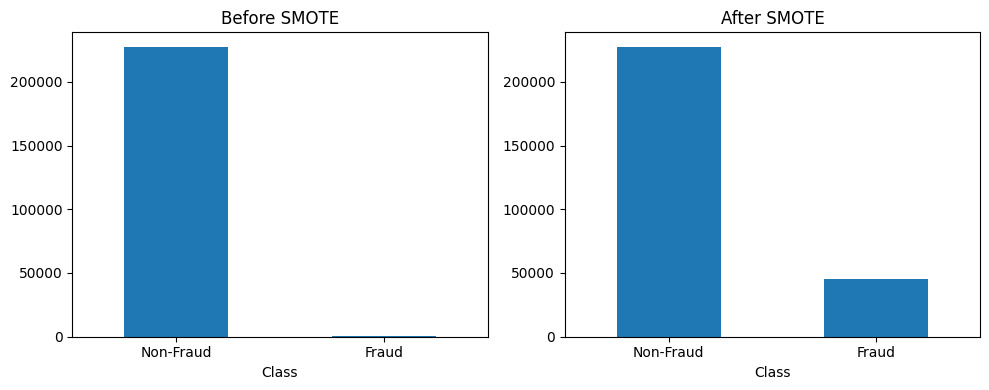

In [42]:
before_counts = y_train.value_counts()
after_counts = y_train_smote.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10,4))

before_counts.plot(
    kind='bar',
    ax=axes[0],
    title='Before SMOTE'
)

after_counts.plot(
    kind='bar',
    ax=axes[1],
    title='After SMOTE'
)

axes[0].set_xticklabels(['Non-Fraud', 'Fraud'], rotation=0)
axes[1].set_xticklabels(['Non-Fraud', 'Fraud'], rotation=0)

plt.tight_layout()

plt.savefig(
    'figures/smote_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Threshold Comparison Figure

Different fraud probability thresholds were evaluated to analyse the trade-off between fraud detection sensitivity and false alarm rates.

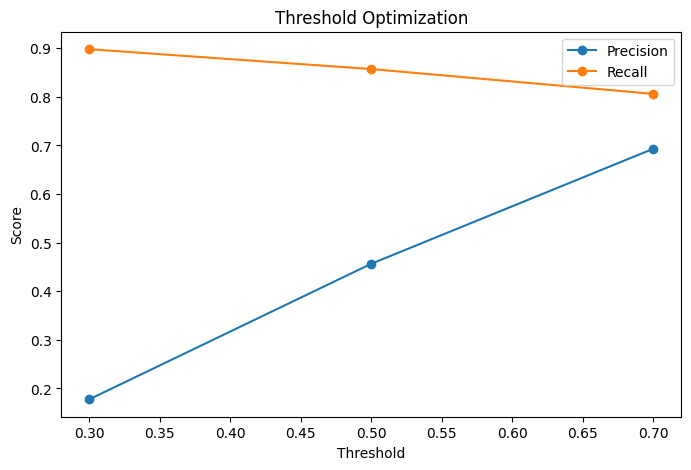

In [43]:
thresholds = [0.3, 0.5, 0.7]

precision_list = []
recall_list = []

for threshold in thresholds:

    custom_pred = (best_prob >= threshold).astype(int)

    precision_list.append(
        precision_score(y_test, custom_pred)
    )

    recall_list.append(
        recall_score(y_test, custom_pred)
    )

plt.figure(figsize=(8,5))

plt.plot(thresholds, precision_list, marker='o', label='Precision')
plt.plot(thresholds, recall_list, marker='o', label='Recall')

plt.title('Threshold Optimization')
plt.xlabel('Threshold')
plt.ylabel('Score')

plt.legend()

plt.savefig(
    'figures/threshold_optimization.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Feature Importance + SHAP Together

In [44]:
import shap

xgb_model = trained_models["XGBoost"]

sample_X_test = X_test.sample(1000, random_state=42)

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(sample_X_test)

shap.summary_plot(
    shap_values,
    sample_X_test,
    show=False
)

plt.savefig(
    'figures/shap_summary_plot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.close()

Precision vs Recall Bar Chart

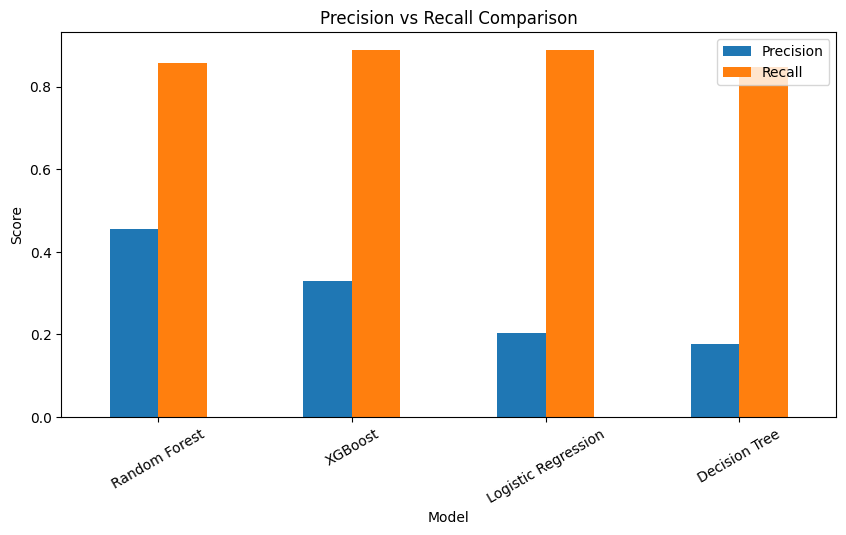

In [45]:
metrics_plot = results_df.set_index('Model')[['Precision', 'Recall']]

metrics_plot.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Precision vs Recall Comparison')
plt.ylabel('Score')

plt.xticks(rotation=30)

plt.savefig(
    'figures/precision_vs_recall.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

False Positive vs False Negative Chart

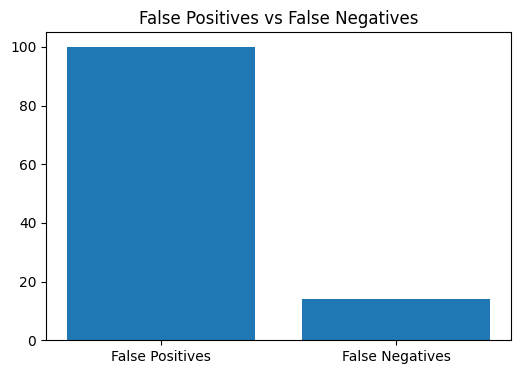

In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_pred)

fp = cm[0][1]
fn = cm[1][0]

plt.figure(figsize=(6,4))

plt.bar(
    ['False Positives', 'False Negatives'],
    [fp, fn]
)

plt.title('False Positives vs False Negatives')

plt.savefig(
    'figures/fp_vs_fn.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Cross Validation Scores Figure

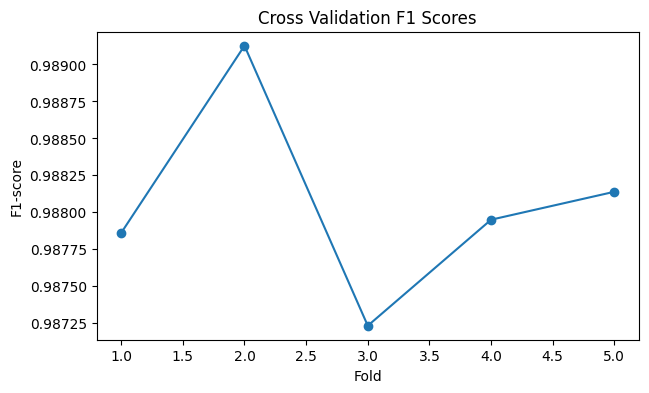

In [47]:
plt.figure(figsize=(7,4))

plt.plot(
    range(1, len(cv_scores)+1),
    cv_scores,
    marker='o'
)

plt.title('Cross Validation F1 Scores')
plt.xlabel('Fold')
plt.ylabel('F1-score')

plt.savefig(
    'figures/cross_validation_scores.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Runtime comparison

,Model,Training Time (seconds)
0,Logistic Regression,8.705112
1,Decision Tree,10.939596
2,Random Forest,69.553678
3,XGBoost,2.350003


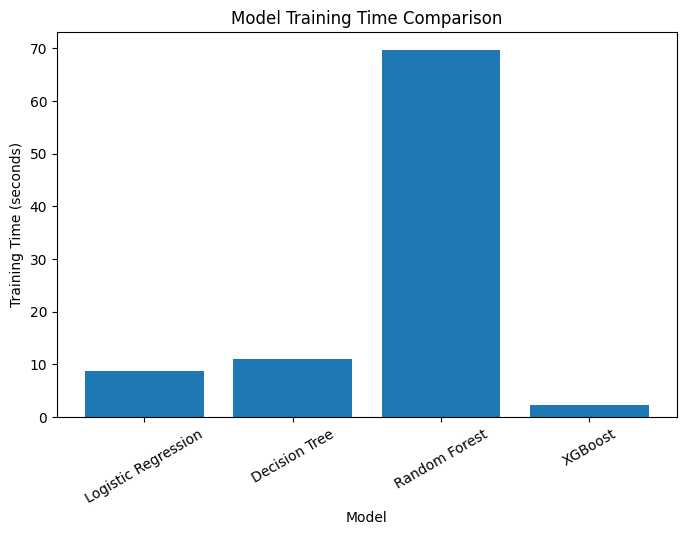

In [48]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)

runtime_results = []

for model_name, model in models.items():
    start_time = time.time()
    model.fit(X_train_smote, y_train_smote)
    end_time = time.time()

    runtime_results.append({
        "Model": model_name,
        "Training Time (seconds)": end_time - start_time
    })

runtime_df = pd.DataFrame(runtime_results)
display(runtime_df)

plt.figure(figsize=(8,5))
plt.bar(runtime_df["Model"], runtime_df["Training Time (seconds)"])
plt.title("Model Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.xticks(rotation=30)
plt.savefig("figures/runtime_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

Create final zip file for GitHub

In [49]:
import zipfile
import os

zip_filename = "fraud_detection_project_final_files.zip"

with zipfile.ZipFile(zip_filename, "w") as zip_file:
    for folder in ["figures", "outputs"]:
        if os.path.exists(folder):
            for root, dirs, files in os.walk(folder):
                for file in files:
                    file_path = os.path.join(root, file)
                    zip_file.write(file_path)

    if os.path.exists("best_fraud_detection_model.pkl"):
        zip_file.write("best_fraud_detection_model.pkl")

    if os.path.exists("model_comparison_results.csv"):
        zip_file.write("model_comparison_results.csv")

print("ZIP file created:", zip_filename)

ZIP file created: fraud_detection_project_final_files.zip
